# A/B-тест Cookie Cats — план работы
 
**Датасет:** Mobile Games A/B Testing (Cookie Cats, Kaggle)
**Стек:** Jupyter + pandas, scipy/statsmodels
**Суть теста:** gate (ворота-блокировка) переносят с 30 уровня (`gate_30`, контроль) на 40 (`gate_40`, тест).
**Бизнес-вопрос:** где ставить gate, чтобы не терять retention.
 
**Поля датасета:**
- `userid` — id игрока
- `version` — группа: `gate_30` / `gate_40`
- `sum_gamerounds` — число сыгранных раундов в первые 14 дней
- `retention_1` — вернулся ли на 1-й день (bool)
- `retention_7` — вернулся ли на 7-й день (bool)
---


## Этап 0. Контекст и гипотеза (до кода)

### Статистические гипотезы

- **H0:** retention_7(gate_30) = retention_7(gate_40) — разницы нет.
- **H1:** retention_7(gate_30) ≠ retention_7(gate_40) — разница есть *(двусторонний тест)*.

### Продуктовые гипотезы о механизме
*(что может стоять за разницей, если она найдётся)*

- **A)** Отодвинутый gate → больше свободной игры → сильнее вовлечение → **выше** возврат.
- **B)** Отодвинутый gate → выгорание за длинные сессии → **ниже** возврат.

Тест покажет, какой механизм перевесил.

### Параметры решения

| Параметр | Значение |
|---|---|
| Уровень значимости α | 0.05 |
| Направление теста | двусторонний |
| MDE | 1 п.п. по retention_7 |

## Этап 1. Загрузка и первичный осмотр



> - [X] `pd.read_csv()` → загрузить `cookie_cats.csv`.

In [ ]:
# Импортируем библиотеку
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from scipy.stats import chisquare
from scipy.stats import norm

df = pd.read_csv('data/cookie_cats.csv')

> - [X]`.head()`, `.info()`, `.describe()` — типы, размер, диапазоны.

In [100]:
# Типы
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [101]:
# размер
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


In [102]:
# диапазон
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


средене mean(52) > медианы 50%(16)
распределение скошено в право
небольшоая группа играков тянет значения в верх, основная масса играет мало
max = 49854 - это выброс
min = 0 - интересное наблюдение для определения качества трафика


> - [X] Пропуски: `.isna().sum()`.


In [103]:
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

> - [X] Дубликаты по игроку: `df['userid'].duplicated().sum()` — должно быть 0.


In [104]:
df['userid'].duplicated().sum()

np.int64(0)

> - [X] Уникальные значения `version` — ровно две группы.


In [105]:
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

>**Done:** Итог этапа 1. Здоровье данных
>
>| Проверка | Результат |
>|---|---|
>| Размер выборки | 90 189 игроков — достаточно с запасом |
>| Пропуски (NaN) | нет |
>| Дубли `userid` | нет, все ID уникальны |
>| Группы `version` | ровно две: `gate_30` (44 700) и `gate_40` (45 489) |
>| Типы данных | корректны; `retention_1` и `retention_7` — булевы (удобно для расчёта долей) |
>| Распределение `sum_gamerounds` | сильный правый скос: медиана 16 при среднем 52, std 195, max 49 854 |
>
>**Флаги на этап 2:** выброс `sum_gamerounds = 49 854` (кандидат на исключение) и скошенность распределения — повлияют на выбор стат-теста.
>
>**Вывод:** данные структурно чистые, группы сбалансированы (≈49.6 / 50.4%), готовы к проверке валидности эксперимента.



## Этап 2. Валидность эксперимента (самый пропускаемый этап)
 
> Если эксперимент сломан — дальше считать бессмысленно. Проверяй здесь, а не после выводов.

 
---


> - [X] **Sample Ratio Mismatch (SRM):** 
размеры групп `value_counts()` по `version`.   
Ожидаешь ~50/50.  
Проверь перекос хи-квадратом против ожидаемого 50/50 (`scipy.stats.chisquare`).   
Если p < 0.001 — есть проблема с рандомизацией.  

In [106]:
# фактические размеры групп
observed = df['version'].value_counts().values

n = len(df)
expected = [n/2, n/2]
chi2, p = chisquare(f_obs=observed, f_exp=expected)

print(f'chi2 = {chi2:.4f}, p-value = {p:.4f}')


chi2 = 6.9024, p-value = 0.0086


> Хи-квадрат дал p = 0.0086 — формально значимо при α = 0.05, но фактический перекос составляет лишь 49.56% против ожидаемых 50%.  
На выборке в 90k наблюдений хи-квадрат избыточно чувствителен к ничтожным отклонениям.  
По порогу SRM-проверки (p < 0.001) расхождение не дотягивает до тревожного.  
Вывод: рандомизация здорова, SRM не обнаружен, эксперимент валиден.  
Практический размер расхождения (0.44%)

> - [X] **Выбросы по `sum_gamerounds`:** найди максимум.  
В этом датасете есть игрок с ~50 000 раундов за 14 дней — это явная аномалия (бот/ошибка).  
Реши, что делаешь: убрать или обрезать, и **обоснуй почему**.

In [107]:
df.sort_values('sum_gamerounds', ascending=False).head(10)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True
46344,5133952,gate_30,2251,True,True
87007,9640085,gate_30,2156,True,True
36933,4090246,gate_40,2124,True,True
88328,9791599,gate_40,2063,True,True
6536,725080,gate_40,2015,True,True


In [108]:
df_clean = df[df['sum_gamerounds'] < 49854]

Выброс userid=6390605 (49 854 раунда) — подтверждённый бот/сбой (≈3500 раундов/день нереально для человека).  
Создан df_clean без этой точки для анализа и визуализации sum_gamerounds.  
Retention считается на полном df — там выброс не искажает доли, а валидные retention_* игрока сохраняются.

> - [X] Сравни распределение `sum_gamerounds` между группами глазами — нет ли утечки/перекоса до всякого эффекта.

In [109]:
df_clean.groupby('version')['sum_gamerounds'].describe()

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44699.0,51.342111,102.057598,0.0,5.0,17.0,50.0,2961.0
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


> **Done:** SRM проверен, решение по выбросу принято и записано с обоснованием.
>
>| Проверка | Результат |
>|---|---|
>| Размер групп (SRM) | gate_30: 44 700, gate_40: 45 489. Перекос 49.56% vs 50% |
>| Хи-квадрат SRM | p = 0.0086 — выше порога 0.001; на выборке 90k шум сверхчувствительности, не поломка |
>| Выброс | `userid=6390605` (49 854 раунда) — бот/сбой, вынесен в `df_clean` для анализа `sum_gamerounds` |
>| Баланс групп по `sum_gamerounds` | mean 51.34 vs 51.30, медиана 17 vs 16 — группы неотличимы |
>
>**Вывод:** эксперимент валиден. Группы сбалансированы по размеру и стартовому поведению. Разницу в ретеншене (если найдётся) можно будет приписывать переносу gate, а не дисбалансу.

## Этап 3. Разведочный анализ (EDA)

 
---


 
> - [X] Гистограмма `sum_gamerounds`.  
> Распределение сильно скошено вправо → построй ещё и в **лог-шкале**, так видно структуру.


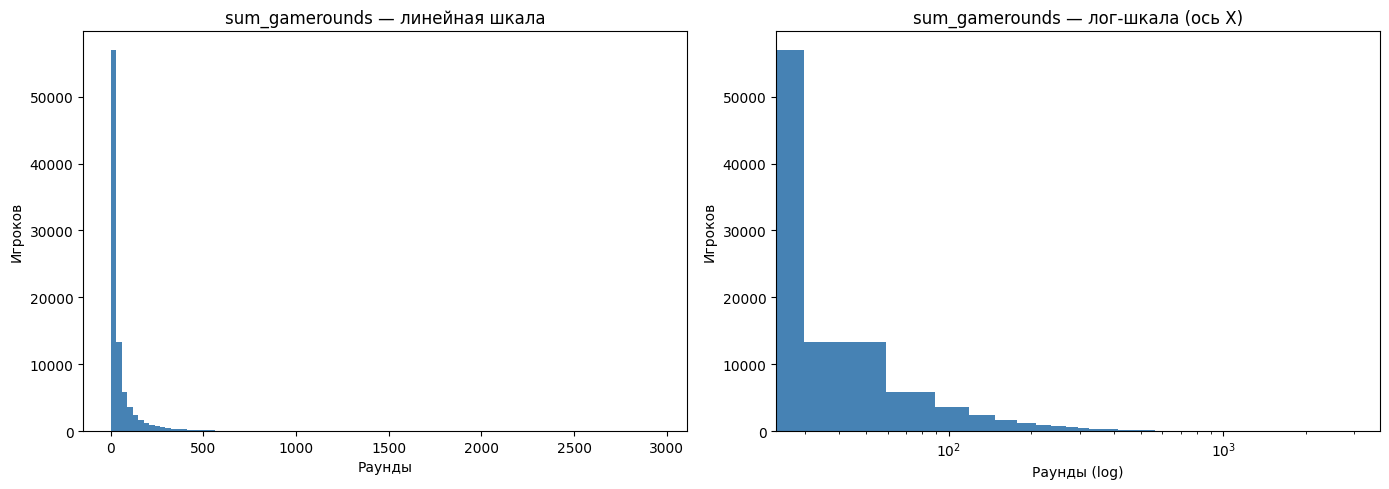

In [95]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Линейная шкала — увидишь, как всё прижато влево
axes[0].hist(df_clean['sum_gamerounds'], bins=100, color='steelblue')
axes[0].set_title('sum_gamerounds — линейная шкала')
axes[0].set_xlabel('Раунды')
axes[0].set_ylabel('Игроков')

# Лог-шкала по X — раскрывает структуру
axes[1].hist(df_clean['sum_gamerounds'], bins=100, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_title('sum_gamerounds — лог-шкала (ось X)')
axes[1].set_xlabel('Раунды (log)')
axes[1].set_ylabel('Игроков')

plt.tight_layout()
plt.show()

> - [X] Доля игроков с `sum_gamerounds == 0` (поставили и не открыли).

In [96]:
zero_players = (df['sum_gamerounds'] == 0).sum()
zero_share = (df['sum_gamerounds'] == 0).mean()
print(f'Игроков с 0 раундов: {zero_players} ({zero_share:.1%})')

Игроков с 0 раундов: 3994 (4.4%)


> Доля нулевых игроков: 3994 (4.4%) установили игру и не сыграли ни одного раунда.  
> Умеренный показатель — большинство хотя бы пробует играть, проблема не в нулях, а в быстром отвале на ранних раундах (медиана всего 16).

> - [X] Базовые доли retention_1 и retention_7 по каждой группе — пока просто `.mean()` по булевым колонкам, без тестов.

In [97]:
df.groupby('version')[['retention_1', 'retention_7']].mean()

,retention_1,retention_7
version,,
gate_30,0.448188,0.190201
gate_40,0.442283,0.182000


> **Done:** Итог этапа 3. Разведочный анализ (EDA)
>
> **Распределение `sum_gamerounds`:** сильный правый скос (типичная F2P-структура). Медиана 16 при среднем 52 — среднее завышено хвостом вовлечённых. Для стат-анализа этой метрики → непараметрические методы.
>
> **Доля нулевых игроков:** 3994 (4.4%) — установили и не сыграли ни разу. Показатель умеренный; основная зона потерь не в нулях, а в раннем отвале (половина игроков ≤16 раундов).
>
> **Базовые доли retention по группам:**
>
> | Метрика | gate_30 | gate_40 | Разница |
> |---|---|---|---|
> | retention_1 | 44.82% | 44.23% | −0.59 п.п. |
> | retention_7 | 19.02% | 18.20% | −0.82 п.п. |
>
> **Наблюдение:** в обеих метриках gate_40 ниже — перенос gate дальше скорее ухудшает удержание (подтверждается продуктовая теория «выгорания», а не «вовлечения»).  
> Разница мала (<MDE 1 п.п.). Статзначимость — на этапе 5, без теста выводы о реальности эффекта не делаем.

## Этап 4. Описательная статистика по группам
 
---

> - [X] Сводная таблица через `groupby('version')`: по каждой группе — `n`, retention_1 (доля), retention_7 (доля), mean и median `sum_gamerounds`.

In [116]:
t1 = df.groupby('version').agg({
    'retention_1' : ['mean', 'sum'],
    'retention_7' : ['mean', 'sum'],
    'userid' : 'size',
})

t2 = df_clean.groupby('version').agg({
    'sum_gamerounds' : ['mean', 'median'],
})

t1.columns = ['mean_retention_1', 'sum_retention_1', 'mean_retention_7', 'sum_retention_7', 'n', ]
t2.columns = ['mean_rounds', 'median_rounds']

result_summary_table = t1.join(t2)
result_summary_table.loc['delta'] = result_summary_table.loc['gate_40'] - result_summary_table.loc['gate_30']
result_summary_table


,mean_retention_1,sum_retention_1,mean_retention_7,sum_retention_7,n,mean_rounds,median_rounds
version,,,,,,,
gate_30,0.448188,20034.0,0.190201,8502.0,44700.0,51.342111,17.0
gate_40,0.442283,20119.0,0.182000,8279.0,45489.0,51.298776,16.0
delta,-0.005905,85.0,-0.008201,-223.0,789.0,-0.043335,-1.0


> **Done:** 

> В сырых данных gate_40 показывает retention ниже на обоих горизонтах (−0.82 п.п. по retention_7), при этом объём игры между группами не различается. Эффект согласован по метрикам, но наблюдаемая разница меньше заложенного MDE — значимость и практическую важность проверяю на этапе 5

## Этап 5. Статистическая проверка
 
Ключевой этап — здесь закрываешь пробел по стате. **Под каждую метрику — свой тест.** Подобрать тест неправильно = частая ошибка на собесе.

 
---


 
### retention_1 и retention_7 (доли, бинарные данные)
- [ ] **z-тест для двух пропорций** → `statsmodels.stats.proportion.proportions_ztest`.
- [ ] Альтернатива/проверка: **хи-квадрат** на таблице сопряжённости → `scipy.stats.chi2_contingency`.
- [ ] ❌ **t-тест здесь некорректен** — данные не непрерывные, это доли. Проговори почему.


In [131]:
def z_test_proportions(s1, s2, n1, n2):
    p1 = s1 / n1
    p2 = s2 / n2
    p  = (s1 + s2) / (n1 + n2)   # pooled из тех же чисел — гарантированно та же выборка
    z = (p1 - p2) / np.sqrt( p*(1-p) * (1/n1 + 1/n2) )
    return z

z_test_retention_7 = z_test_proportions(
    result_summary_table.loc['gate_30', 'sum_retention_7'],
    result_summary_table.loc['gate_40', 'sum_retention_7'],
    result_summary_table.loc['gate_30', 'n'],
    result_summary_table.loc['gate_40', 'n'],
)

print(f'z-тест для retention_7 = {z_test_retention_7}')

z-тест для retention_7 = 3.164358912748191


### sum_gamerounds (числовая, но распределение скошено)
- [ ] t-тест на средних **рискован** из-за сильной скошенности и выброса.
- [ ] Надёжнее: **Манн-Уитни** (`scipy.stats.mannwhitneyu`) — сравнивает распределения, не требует нормальности.
- [ ] Ещё надёжнее и нагляднее: **bootstrap** разницы средних (см. этап 6).


### Интерпретация p-value
- [ ] Запиши своими словами: что p-value значит и **чего НЕ значит** (это не вероятность того, что H₀ верна, и не размер эффекта).
**Done:** для каждой метрики выбран и обоснован тест, посчитаны p-value, есть корректная интерпретация.

## Этап 6. Размер эффекта и доверительные интервалы
 
p-value без размера эффекта — половина ответа. «Значимо» ≠ «важно для бизнеса».
 
- [ ] **Абсолютная разница** retention_7: `p_тест − p_контроль` (в процентных пунктах).
- [ ] **Относительная разница:** на сколько % изменился retention.
- [ ] **Доверительный интервал** для разницы пропорций → `statsmodels.stats.proportion.confint_proportions_2indep`.
- [ ] **Bootstrap** для retention_7: 1000+ ресэмплов с возвращением, посчитай разницу долей на каждом, построй распределение и 95% перцентильный интервал. Покажи, по какую сторону нуля лежит масса.
**Done:** есть размер эффекта (абс. и отн.) и доверительный интервал; можешь сказать не только «значимо/нет», но и «насколько».
 
---


## Этап 7. Размер выборки / мощность (обратная проверка)
 
- [ ] Power analysis → `statsmodels.stats.power` / `proportion_effectsize` + `NormalIndPower`.
- [ ] Прикинь: какой минимальный эффект ты способен задетектить при текущем n с power 0.8.
- [ ] Объясни словами: почему маленькая, но реальная разница может оказаться незначимой — это про мощность, а не про отсутствие эффекта.
**Done:** понимаешь минимально детектируемый эффект (MDE) и умеешь объяснить связь n ↔ мощность ↔ значимость.
 
---


## Этап 8. Выводы и рекомендация бизнесу
 
- [ ] Один абзац рекомендации: оставлять gate на 30 или двигать на 40 — **с цифрами и оговорками**.
- [ ] Явно сошлись на первичную метрику (retention_7), а не на ту, где результат «красивее».
- [ ] Что проверить дальше: сегменты (новички vs вовлечённые), длительность теста, влияние на монетизацию.
- [ ] Ограничения анализа: что осталось за кадром (только 14 дней, нет данных по выручке и т.п.).
**Done:** есть короткая, честная рекомендация с числами; есть список next steps и ограничений.
 
---


## Чек на выходе (для портфолио и собеса)
 
- [ ] Ноутбук читается сверху вниз как история: вопрос → проверки → тесты → вывод.
- [ ] Каждый выбор теста обоснован текстом, не только кодом.
- [ ] Есть размер эффекта и CI, а не только p-value.
- [ ] Финальный вывод сформулирован для бизнеса, без статистического жаргона.
- [ ] Можешь за 2 минуты устно рассказать, что делал и к чему пришёл.
